In [13]:
import torch
from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

device

'cuda'

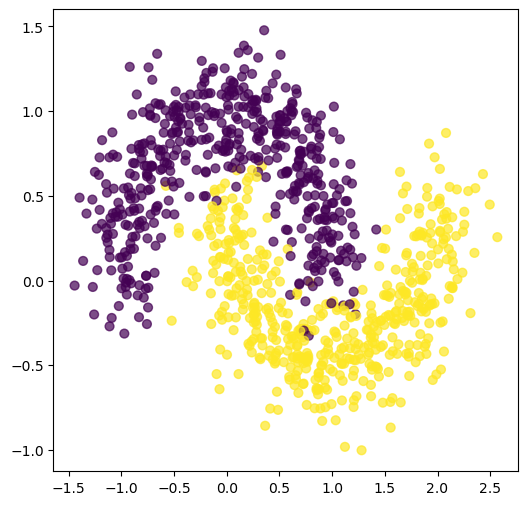

In [14]:
plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=40,
    alpha=0.7
)

plt.show()

In [15]:
from torch import nn

class MoonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # add relu for curves

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

MM = MoonModel()
MM

MoonModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(MM.parameters(), lr=0.1)

In [17]:

# What's coming out of our model?

# logits (raw outputs of model)
y_logits = MM(X_test).squeeze()
print("Logits: ", y_logits[:10])  # first 10 samples

# Prediction probabilities
y_probs = torch.sigmoid(y_logits)
print("Pred probs: ", y_probs[:10])

# Prediction labels
y_labels = torch.round(y_probs)
print("Pred labels: ", y_labels[:10])

Logits:  tensor([-0.2302, -0.2765, -0.2022, -0.3186, -0.1766, -0.1627, -0.2514, -0.2493,
        -0.1501, -0.2986], grad_fn=<SliceBackward0>)
Pred probs:  tensor([0.4427, 0.4313, 0.4496, 0.4210, 0.4560, 0.4594, 0.4375, 0.4380, 0.4625,
        0.4259], grad_fn=<SliceBackward0>)
Pred labels:  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)


In [22]:
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
accuracy_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
accuracy_fn
     

MulticlassAccuracy()

In [26]:
torch.manual_seed(42)
epochs = 10001

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
MM = MM.to(device)

for epoch in range(epochs):

    MM.train()
    
    #1 forward pass
    y_logits = MM(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2 calc loss and acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_pred, y_train)

    # 3 optimizer
    optimizer.zero_grad()

    # 4 loss back
    loss.backward()

    # 5 step
    optimizer.step()

    #test
    MM.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = MM(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(test_pred, y_test)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.68374, Accuracy: 0.50% | Test Loss: 0.68269, Test Accuracy: 0.50%
Epoch: 100 | Loss: 0.31417, Accuracy: 0.86% | Test Loss: 0.32578, Test Accuracy: 0.85%
Epoch: 200 | Loss: 0.25846, Accuracy: 0.88% | Test Loss: 0.25580, Test Accuracy: 0.88%
Epoch: 300 | Loss: 0.23084, Accuracy: 0.90% | Test Loss: 0.22298, Test Accuracy: 0.90%
Epoch: 400 | Loss: 0.19883, Accuracy: 0.92% | Test Loss: 0.18834, Test Accuracy: 0.92%
Epoch: 500 | Loss: 0.16481, Accuracy: 0.93% | Test Loss: 0.15187, Test Accuracy: 0.94%
Epoch: 600 | Loss: 0.13584, Accuracy: 0.95% | Test Loss: 0.12039, Test Accuracy: 0.96%
Epoch: 700 | Loss: 0.11596, Accuracy: 0.96% | Test Loss: 0.09815, Test Accuracy: 0.98%
Epoch: 800 | Loss: 0.10301, Accuracy: 0.96% | Test Loss: 0.08360, Test Accuracy: 0.98%
Epoch: 900 | Loss: 0.09424, Accuracy: 0.97% | Test Loss: 0.07369, Test Accuracy: 0.98%
Epoch: 1000 | Loss: 0.08870, Accuracy: 0.97% | Test Loss: 0.06729, Test Accuracy: 0.98%
Epoch: 1100 | Loss: 0.08497, Accuracy: 0.97%

In [27]:
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

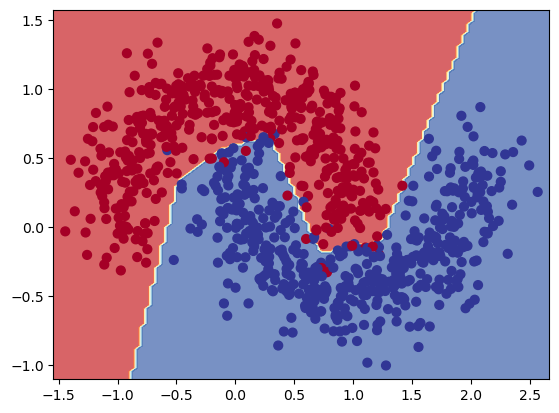

In [28]:
plot_decision_boundary(MM, X, y)

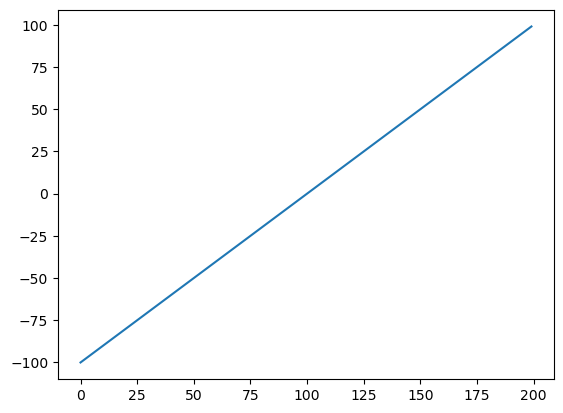

In [46]:
tensor_A = torch.arange(-100, 100, 1)
plt.plot(tensor_A)

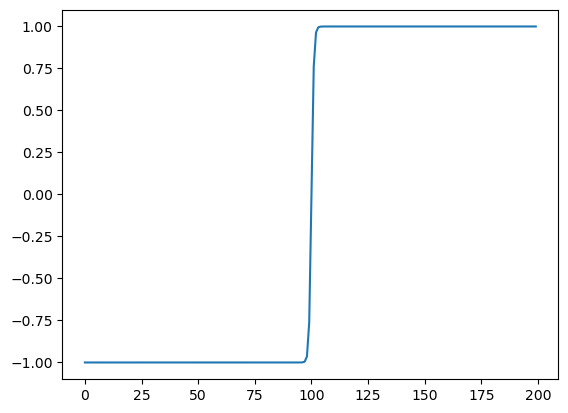

In [47]:
plt.plot(torch.tanh(tensor_A))

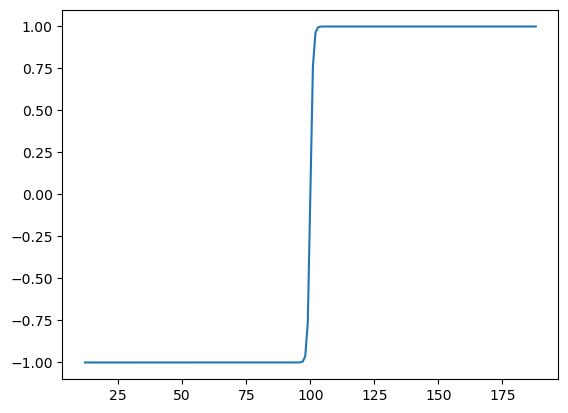

In [48]:
def tanh(x):
  # Source - https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh
  return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(tanh(tensor_A))